## Modelo Híbrido

# ¿Cómo funciona?

Este notebook combina los dos modelos anteriores para generar recomendaciones más precisas y variadas.

## Idea general

Cada modelo produce un score independiente para cada canción:

- **Content-Based** → score_contenido basado en similitud de audio
- **Collaborative** → score_colaborativo basado en patrones de usuarios similares

Ambos scores se normalizan al rango [0, 1] y se combinan con un peso α:


score_final = α × score_contenido + (1 - α) × score_colaborativo


## Qué hace este notebook

- Carga el modelo SVD guardado en collaborative.ipynb
- Reconstruye el modelo Content-Based desde items.csv
- Combina ambos scores con ponderación ajustable
- Genera recomendaciones finales con título, artista, género y score
- Permite comparar los tres modelos lado a lado

# Importaciones

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
from IPython.display import display
from scipy.sparse import hstack, csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style='whitegrid')
np.random.seed(42)

# Paths con fallback igual que en los notebooks anteriores
def resolve_path(primary, fallback):
    p = Path(primary)
    return p if p.exists() else Path(fallback)

ITEMS_PATH        = resolve_path('/data/processed/items.csv',        '../../data/processed/items.csv')
INTERACTIONS_PATH = resolve_path('/data/processed/interactions.csv', '../../data/processed/interactions.csv')
MODEL_PATH        = resolve_path('/data/processed/modelo_svd.pkl',   '../../data/processed/modelo_svd.pkl')

# Features de audio para Content-Based
AUDIO_FEATURES = [
    'danceability', 'energy', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'loudness_norm', 'tempo_norm'
]

# Peso del modelo de contenido (0 = solo colaborativo, 1 = solo contenido)
ALPHA = 0.5

# Carga de Datos y Modelos

In [6]:
# Datos
items = pd.read_csv(ITEMS_PATH)
interactions = pd.read_csv(INTERACTIONS_PATH)

# Consolidar filas duplicadas por ITEM_ID: título/artista = first, género = lista única, popularidad = media
items_indexed = (
    items
    .groupby('ITEM_ID')
    .agg({
        'titulo': 'first',
        'artista': 'first',
        'genero': lambda g: ','.join(sorted(set(g.dropna().astype(str)))),
        'popularidad': 'mean'
    })
    .reset_index()
    .set_index('ITEM_ID')
)

print(f'Canciones: {len(items):,}')
print(f'Interacciones: {len(interactions):,}')

Canciones: 114,000
Interacciones: 750,050


In [9]:
# Modelo colaborativo (guardado por 02_collaborative.ipynb)
with open(MODEL_PATH, 'rb') as f:
    modelo_svd = pickle.load(f)

user_to_idx = modelo_svd['user_to_idx']
item_to_idx = modelo_svd['item_to_idx']
idx_to_item = modelo_svd['idx_to_item']

U = modelo_svd.get('U', modelo_svd.get('U_train'))
S = modelo_svd.get('S', modelo_svd.get('S_train'))
Vt = modelo_svd.get('Vt', modelo_svd.get('Vt_train'))
media_usuarios = modelo_svd.get('media_usuarios', modelo_svd.get('media_u_train'))
factores_usuario = modelo_svd.get('factores_usuario', modelo_svd.get('factores_usuario_train'))  # U × Σ

print('Modelo SVD cargado')
print(f'Usuarios en el modelo: {len(user_to_idx):,}')
print(f'Canciones en el modelo: {len(item_to_idx):,}')

Modelo SVD cargado
Usuarios en el modelo: 15,001
Canciones en el modelo: 89,639


# Preparación de modelo content_based

In [10]:
# Matriz de features para Content-Based
# El CSV no trae features de audio, así que usamos género, artista y popularidad.
genre_matrix = csr_matrix(items_indexed['genero'].fillna('').astype(str).str.get_dummies(sep=',').to_numpy(dtype=np.float32))
artist_matrix = pd.get_dummies(items_indexed['artista'].fillna('').astype(str), prefix='artist', sparse=True)
artist_matrix = artist_matrix.sparse.to_coo().tocsr()
popularidad = items_indexed['popularidad'].fillna(0).to_numpy(dtype=float).reshape(-1, 1)

if popularidad.max() > popularidad.min():
    popularidad = (popularidad - popularidad.min()) / (popularidad.max() - popularidad.min())

feature_matrix = hstack([genre_matrix, artist_matrix, csr_matrix(popularidad)], format='csr')
item_ids_list  = items_indexed.index.tolist()
cb_item_to_idx = {item_id: idx for idx, item_id in enumerate(item_ids_list)}

print(f'Matriz de features: {feature_matrix.shape}')
print(f' -> géneros: {genre_matrix.shape[1]}, artistas: {artist_matrix.shape[1]}, popularidad: 1')

Matriz de features: (89741, 31553)
 -> géneros: 114, artistas: 31438, popularidad: 1


# Funciones de Recomendación

In [11]:
def scores_content_based(user_id: str) -> np.ndarray:
    """
    Calcula el score de similitud de coseno entre el perfil
    de audio del usuario y todas las canciones.
    Retorna un array de shape (n_canciones_items,)
    """
    likes = interactions[
        (interactions['USER_ID'] == user_id) &
        (interactions['EVENT_TYPE'] == 'like')
    ]['ITEM_ID'].tolist()

    if not likes:
        # Fallback: usar plays si no tiene likes
        likes = interactions[
            (interactions['USER_ID'] == user_id) &
            (interactions['EVENT_TYPE'] == 'play')
        ]['ITEM_ID'].tolist()

    if not likes:
        return np.zeros(len(item_ids_list))

    indices = [cb_item_to_idx[i] for i in likes if i in cb_item_to_idx]
    perfil  = np.asarray(feature_matrix[indices].mean(axis=0)).ravel().reshape(1, -1)
    return cosine_similarity(perfil, feature_matrix).flatten()


def scores_collaborative(user_id: str) -> np.ndarray:
    """
    Calcula el rating predicho por SVD para todas las canciones del modelo.
    Retorna un array de shape (n_canciones_modelo,)
    """
    if user_id not in user_to_idx:
        return np.zeros(len(item_to_idx))

    u_idx = user_to_idx[user_id]
    # factores_usuario[u] @ Vt reproduce la fila del usuario sin materializar R_pred completa
    return factores_usuario[u_idx] @ Vt + media_usuarios[u_idx]


def normalizar(arr: np.ndarray) -> np.ndarray:
    """Normaliza un array al rango [0, 1]."""
    min_v, max_v = arr.min(), arr.max()
    if max_v == min_v:
        return np.zeros_like(arr)
    return (arr - min_v) / (max_v - min_v)


print('Funciones de scoring definidas')

Funciones de scoring definidas


In [12]:
def recomendar_hibrido(user_id: str, n: int = 10, alpha: float = ALPHA, max_por_artista: int = 1, max_por_genero: int = 2) -> pd.DataFrame:
    """
    Recomienda las N mejores canciones combinando Content-Based y Collaborative.

    Parámetros:
        user_id : ID del usuario
        n       : número de recomendaciones
        alpha   : peso del score de contenido (0=solo collab, 1=solo content)
        max_por_artista : máximo de canciones por artista en el top-N
        max_por_genero : máximo de apariciones por género en el top-N

    Retorna:
        DataFrame con columnas: ITEM_ID, titulo, artista, genero, popularidad,
                                score_contenido, score_colaborativo, score_final
    """
    # Canciones ya escuchadas por el usuario
    ya_vistas = set(interactions[interactions['USER_ID'] == user_id]['ITEM_ID'].tolist())

    # Content-Based 
    sc_raw = scores_content_based(user_id)
    # array sobre items.csv
    sc_norm = normalizar(sc_raw)

    #  Collaborative 
    scol_raw  = scores_collaborative(user_id)
    # array sobre canciones del modelo
    scol_norm = normalizar(scol_raw)

    # Combinar en un DataFrame común 
    # Content-based cubre todos los items; collaborative solo los que vio en entrenamiento
    df_cb = pd.DataFrame({
        'ITEM_ID'           : item_ids_list,
        'score_contenido'   : sc_norm
    })

    df_col = pd.DataFrame({
        'ITEM_ID'             : [idx_to_item[i] for i in range(len(scol_norm))],
        'score_colaborativo'  : scol_norm
    })

    df = df_cb.merge(df_col, on='ITEM_ID', how='left')
    df['score_colaborativo'] = df['score_colaborativo'].fillna(0)

    # Score final 
    df['score_final'] = alpha * df['score_contenido'] + (1 - alpha) * df['score_colaborativo']

    # Excluir ya vistas y ordenar 
    df = df[~df['ITEM_ID'].isin(ya_vistas)]
    df = df.sort_values('score_final', ascending=False)

    # Traer metadata antes del re-ranking para tener acceso a artista/título/género
    meta = items_indexed[['titulo', 'artista', 'genero', 'popularidad']].reset_index()
    df = df.merge(meta, on='ITEM_ID', how='left')

    # Re-ranking simple para evitar que un mismo artista monopolice el top-N
    seleccionados = []
    contador_artistas = {}
    contador_generos = {}
    for _, fila in df.iterrows():
        artista = fila['artista']
        generos_fila = [g.strip() for g in str(fila['genero']).split(',') if g.strip()]
        contador_artistas[artista] = contador_artistas.get(artista, 0)
        puede_agregar = contador_artistas[artista] < max_por_artista
        if puede_agregar and generos_fila:
            for genero in generos_fila:
                if contador_generos.get(genero, 0) >= max_por_genero:
                    puede_agregar = False
                    break
        if puede_agregar:
            seleccionados.append(fila)
            contador_artistas[artista] += 1
            for genero in generos_fila:
                contador_generos[genero] = contador_generos.get(genero, 0) + 1
        if len(seleccionados) == n:
            break

    # Si el filtro deja menos de n resultados, completar sin restricción
    if len(seleccionados) < n:
        faltantes = n - len(seleccionados)
        restantes = df[~df['ITEM_ID'].isin([x['ITEM_ID'] for x in seleccionados])].head(faltantes)
        seleccionados.extend(restantes.to_dict('records'))

    resultado = pd.DataFrame(seleccionados).head(n)

    cols = ['ITEM_ID', 'titulo', 'artista', 'genero', 'popularidad',
            'score_contenido', 'score_colaborativo', 'score_final']
    return resultado[cols].reset_index(drop=True)


print('Función recomendar_hibrido() definida')

Función recomendar_hibrido() definida


# Prueba con Usuario Real

In [15]:
# Usuario con más likes para una prueba representativa
usuario_prueba = interactions[
    interactions['EVENT_TYPE'] == 'like'
]['USER_ID'].value_counts().index[0]

likes = interactions[
    (interactions['USER_ID'] == usuario_prueba) &
    (interactions['EVENT_TYPE'] == 'like')
]['ITEM_ID'].tolist()

print(f'Usuario de prueba: {usuario_prueba} ({len(likes)} likes)')
print('\nSus likes:')
items_indexed.loc[
    [i for i in likes[:5] if i in items_indexed.index],
    ['titulo', 'artista', 'genero']
]

Usuario de prueba: user_4558 (36 likes)

Sus likes:


,titulo,artista,genero
ITEM_ID,,,
3jwcudvYIksoAjU0x6gagd,Valerie,Steve Winwood,"country,folk,singer-songwriter,songwriter"
7tCL3GNUc04W2S7Cx1MzId,Serene Rain,Deep Sleep Rain Sounds,sleep
1wrSlSMgdb4STao5UKN5ML,Rough Day,Rain Sounds,sleep
76CSHuHKMJxmjmdrNBX2Z3,Victoria’s Secret,Jax,"singer-songwriter,songwriter"
1kJvdhrr9MHOZ1e1PhTXTG,Drown,Prateek Kuhad,"folk,indie-pop,singer-songwriter,songwriter"


In [16]:
recomendaciones = recomendar_hibrido(usuario_prueba, n=10, alpha=ALPHA)
print(f'Top 10 recomendaciones híbridas para {usuario_prueba} (α={ALPHA}):')
recomendaciones

Top 10 recomendaciones híbridas para user_4558 (α=0.5):


,ITEM_ID,titulo,artista,genero,popularidad,score_contenido,score_colaborativo,score_final
0,6q7bXTv3yBedHblKRoC5uu,Kadam,Prateek Kuhad,"folk,indian,indie,indie-pop,singer-songwriter,...",51.0,0.806480,0.511552,0.659016
1,77Y57qRJBvkGCUw9qs0qMg,In the Blood,John Mayer,"singer-songwriter,songwriter",62.0,0.942279,0.364258,0.653268
2,3hs7Lh777aKJugwl0Zq1QF,Sleep Rain,Rain Sounds,sleep,54.0,0.847810,0.228547,0.538179
3,2gdCsrNrQlMj2EFnsMFUHA,Weißes Rauschen: Baby Schlafhilfe,Weißes Rauschen HD,sleep,67.0,0.835392,0.234802,0.535097
4,2pUpNOgJBIBCcjyQZQ00qU,Let Her Go,Passenger,folk,75.0,0.418975,0.272534,0.345755
5,7nzsY8vlnKdvGOEE0rjAXZ,Arabella,Arctic Monkeys,"garage,indie,rock",78.0,0.277675,0.376620,0.327148
6,2Z8WuEywRWYTKe1NybPQEW,Ride,Twenty One Pilots,rock,82.0,0.349958,0.255286,0.302622
7,3WMj8moIAXJhHsyLaqIIHI,Something in the Orange,Zach Bryan,country,89.0,0.364662,0.231409,0.298036
8,4686eQ81DEswHa90bcdlC9,Rock and A Hard Place,Bailey Zimmerman,country,84.0,0.354273,0.237407,0.295840
9,3pANfZVFdtuVnJsE6xa5Ox,Me and My Husband,Mitski,indie-pop,77.0,0.310644,0.247270,0.278957


# Comparación entre modelos

In [17]:
# Recomendaciones de cada modelo por separado
solo_content = recomendar_hibrido(usuario_prueba, n=10, alpha=1.0)
solo_collab  = recomendar_hibrido(usuario_prueba, n=10, alpha=0.0)
hibrido      = recomendar_hibrido(usuario_prueba, n=10, alpha=0.5)

def estilo_tabla(df):
    return (
        df.style
        .hide(axis='index')
        .format({
            'score_contenido': '{:.3f}',
            'score_colaborativo': '{:.3f}',
            'score_final': '{:.3f}',
            'popularidad': '{:.1f}'
        })
        .background_gradient(subset=['score_final'], cmap='Blues')
        .set_properties(**{'text-align': 'left'})
    )

print('── Solo Content-Based (α=1.0) ──')
display(estilo_tabla(solo_content))

print('\n── Solo Collaborative (α=0.0) ──')
display(estilo_tabla(solo_collab))

print('\n── Híbrido (α=0.5) ──')
display(estilo_tabla(hibrido))

── Solo Content-Based (α=1.0) ──


ITEM_ID,titulo,artista,genero,popularidad,score_contenido,score_colaborativo,score_final
32Gf5A7Hr8RdgggXG0Fdks,Have You Ever Really Loved A Woman?,Bryan Adams,"singer-songwriter,songwriter",71.0,1.000,0.264,1.000
4svaKoxMMP7ImmKrD5hfQu,Victoria’s Secret,Jax,"singer-songwriter,songwriter",82.0,0.984,0.244,0.984
3hs7Lh777aKJugwl0Zq1QF,Sleep Rain,Rain Sounds,sleep,54.0,0.848,0.229,0.848
7EbAGbBeU3SRzRnhpfcVHY,Brown Noise For Sleep 9,Granular,sleep,49.0,0.840,0.230,0.840
1Fid2jjqsHViMX6xNH70hE,Atlantis,Seafret,folk,90.0,0.448,0.230,0.448
7yq4Qj7cqayVTp3FF9CWbm,Riptide,Vance Joy,"folk,rock",82.0,0.440,0.237,0.440
2LawezPeJhN4AWuSB0GtAU,Have You Ever Seen The Rain,Creedence Clearwater Revival,"country,rock",83.5,0.372,0.226,0.372
3WMj8moIAXJhHsyLaqIIHI,Something in the Orange,Zach Bryan,country,89.0,0.365,0.231,0.365
6QeYSvYqYUsfBzsApbjDHO,Cigarettes out the Window,TV Girl,indie-pop,80.0,0.318,0.235,0.318
5411TEB6tlzvuF5A4oyldr,Francis Forever,Mitski,indie-pop,78.0,0.313,0.235,0.313



── Solo Collaborative (α=0.0) ──


ITEM_ID,titulo,artista,genero,popularidad,score_contenido,score_colaborativo,score_final
0T7DQlfcadEUEjxoHeQQaL,Labios Rotos - En Vivo,Zoé,"alt-rock,alternative,indie,latin,rock",0.0,0.092,0.521,0.521
6q7bXTv3yBedHblKRoC5uu,Kadam,Prateek Kuhad,"folk,indian,indie,indie-pop,singer-songwriter,songwriter",51.0,0.806,0.512,0.512
4aqS25F3ywJ9TGnNkOqilC,Abracadabra - Remastered 2017,Steve Miller Band,"blues,country,folk,hard-rock,psych-rock,singer-songwriter,songwriter",2.3,0.629,0.433,0.433
5t9YU2mww4eiFCeTBy3EFU,One More Round (Free Fire Booyah Day Theme Song),KSHMR;Jeremy Oceans,"edm,electro,house,indian,progressive-house",53.0,0.131,0.415,0.415
5y0nMZC5kF6uLYaLc97mSo,Loco Contigo,DJ Snake;J Balvin;Tyga,"dance,edm,electro,electronic",0.0,0.000,0.341,0.341
7b3OfGX7LuIyTBk6FMdagF,Teardrinker,Mastodon,"alt-rock,groove,hard-rock,metal",0.0,0.000,0.340,0.340
1T0NvgD6SHsWLwPsK75en8,Guaya Guaya,Don Omar,"hip-hop,latin,latino,reggae,reggaeton",1.0,0.002,0.324,0.324
076sWQZiNFZq605udzIw8N,(Love Is Like A) Heat Wave - Single Version,Martha Reeves & The Vandellas,"disco,funk,r-n-b,rock-n-roll,soul",0.0,0.000,0.310,0.310
5YfYbZ4bgXC7iBzeVCR8qI,"Something About You - 7"" Version",Level 42,"disco,funk,r-n-b,synth-pop",0.0,0.000,0.308,0.308
3sjiHBkn28c9FDyasXJqZf,my girl,Shiloh Dynasty;Shiloh Beat,"chill,sad",55.0,0.161,0.303,0.303



── Híbrido (α=0.5) ──


ITEM_ID,titulo,artista,genero,popularidad,score_contenido,score_colaborativo,score_final
6q7bXTv3yBedHblKRoC5uu,Kadam,Prateek Kuhad,"folk,indian,indie,indie-pop,singer-songwriter,songwriter",51.0,0.806,0.512,0.659
77Y57qRJBvkGCUw9qs0qMg,In the Blood,John Mayer,"singer-songwriter,songwriter",62.0,0.942,0.364,0.653
3hs7Lh777aKJugwl0Zq1QF,Sleep Rain,Rain Sounds,sleep,54.0,0.848,0.229,0.538
2gdCsrNrQlMj2EFnsMFUHA,Weißes Rauschen: Baby Schlafhilfe,Weißes Rauschen HD,sleep,67.0,0.835,0.235,0.535
2pUpNOgJBIBCcjyQZQ00qU,Let Her Go,Passenger,folk,75.0,0.419,0.273,0.346
7nzsY8vlnKdvGOEE0rjAXZ,Arabella,Arctic Monkeys,"garage,indie,rock",78.0,0.278,0.377,0.327
2Z8WuEywRWYTKe1NybPQEW,Ride,Twenty One Pilots,rock,82.0,0.350,0.255,0.303
3WMj8moIAXJhHsyLaqIIHI,Something in the Orange,Zach Bryan,country,89.0,0.365,0.231,0.298
4686eQ81DEswHa90bcdlC9,Rock and A Hard Place,Bailey Zimmerman,country,84.0,0.354,0.237,0.296
3pANfZVFdtuVnJsE6xa5Ox,Me and My Husband,Mitski,indie-pop,77.0,0.311,0.247,0.279


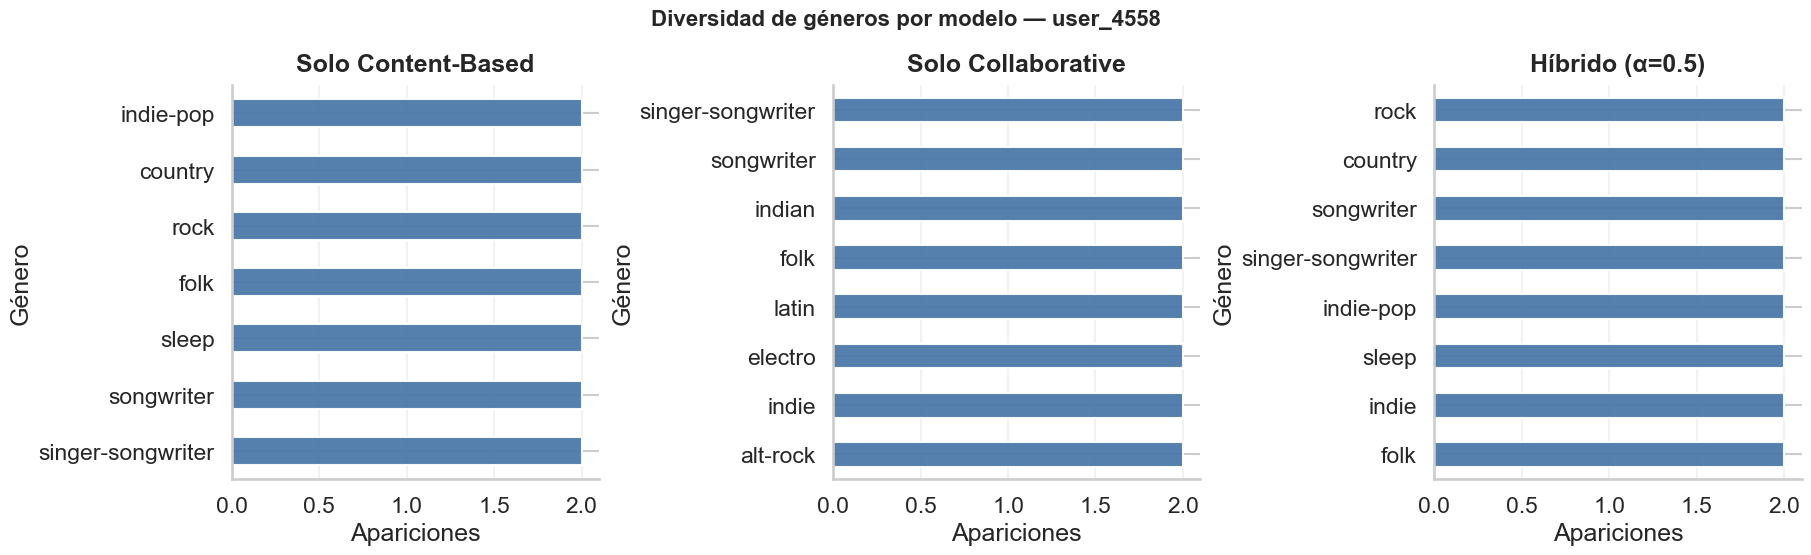

In [18]:
# Diversidad de géneros por modelo
sns.set_theme(style='whitegrid', context='talk')
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
fig.patch.set_facecolor('white')

for ax, (titulo, df) in zip(axes, [
    ('Solo Content-Based', solo_content),
    ('Solo Collaborative', solo_collab),
    ('Híbrido (α=0.5)',    hibrido)
]):
    generos = (
        df['genero']
        .fillna('')
        .astype(str)
        .str.split(',')
        .explode()
        .str.strip()
    )
    generos = generos[generos != '']
    top_generos = generos.value_counts().head(8)
    top_generos.sort_values().plot(kind='barh', ax=ax, color='#4C78A8', edgecolor='white', alpha=0.95)
    ax.set_title(titulo, pad=10, fontweight='bold')
    ax.set_xlabel('Apariciones')
    ax.set_ylabel('Género')
    ax.grid(axis='x', alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle(f'Diversidad de géneros por modelo — {usuario_prueba}', y=1.08, fontsize=16, fontweight='bold')
plt.show()

# Efecto de α en las Recomendaciones

In [19]:
# Ver cómo cambia el score_final según alpha
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]

print(f'Top 5 canciones para {usuario_prueba} según α:\n')
print(f'{"Canción":<35} {" | ".join([f"α={a}" for a in alphas])}')
print('-' * 80)

for a in alphas:
    top5 = recomendar_hibrido(usuario_prueba, n=5, alpha=a)
    print(f'\nα = {a}')
    print(top5[['titulo', 'genero', 'score_final']].to_string(index=False))

Top 5 canciones para user_4558 según α:

Canción                             α=0.0 | α=0.25 | α=0.5 | α=0.75 | α=1.0
--------------------------------------------------------------------------------

α = 0.0
                                          titulo                                                               genero  score_final
                          Labios Rotos - En Vivo                                alt-rock,alternative,indie,latin,rock     0.521466
                                           Kadam             folk,indian,indie,indie-pop,singer-songwriter,songwriter     0.511552
                   Abracadabra - Remastered 2017 blues,country,folk,hard-rock,psych-rock,singer-songwriter,songwriter     0.432886
One More Round (Free Fire Booyah Day Theme Song)                           edm,electro,house,indian,progressive-house     0.414620
                                    Loco Contigo                                         dance,edm,electro,electronic     0.340850

α = 0.

# Prueba con cualquier usuario

In [22]:
USER_ID_PRUEBA    = 'user_5001'
N_RECOMENDACIONES = 5
ALPHA_PRUEBA      = 0.5

resultado = recomendar_hibrido(USER_ID_PRUEBA, n=N_RECOMENDACIONES, alpha=ALPHA_PRUEBA)
print(f'Recomendaciones híbridas para {USER_ID_PRUEBA} (α={ALPHA_PRUEBA}):')
resultado

Recomendaciones híbridas para user_5001 (α=0.5):


,ITEM_ID,titulo,artista,genero,popularidad,score_contenido,score_colaborativo,score_final
0,3QuH98etXysoPyuRqrAUms,Mother in Law,Vybz Kartel,"dancehall,j-dance",25.0,0.984238,0.617597,0.800917
1,48eDHR9rcXM4qpJwfXyUhG,Unbreakable,Rygin King,"dancehall,j-dance",28.0,0.939063,0.624242,0.781652
2,5h1L6nOR9QYXeeNW14aeus,Pause,Prateek Kuhad,"folk,indian,indie,indie-pop,singer-songwriter,...",51.0,0.106736,0.926700,0.516718
3,2Ey6v4Sekh3Z0RUSISRosD,Layla,Derek & The Dominos,"blues,british,country,folk,hard-rock,psych-roc...",0.0,0.000000,1.000000,0.500000
4,2aibwv5hGXSgw7Yru8IYTO,Snow (Hey Oh),Red Hot Chili Peppers,"alt-rock,alternative,funk,metal,rock",80.0,0.098118,0.822148,0.460133
